1. Download a public time series dataset of daily temperature for any Indian city (e.g., from Kaggle or data.gov.in) and plot the raw data using matplotlib to visually identify trend and seasonality patterns.

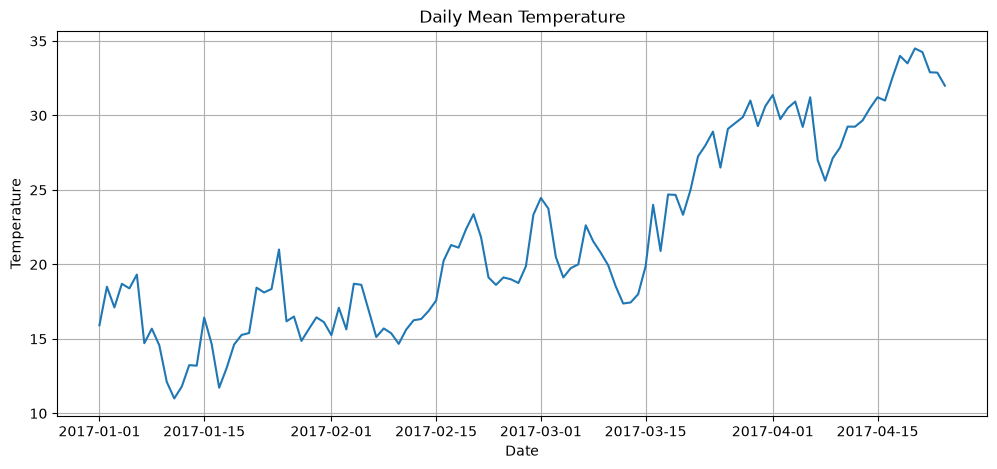

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("DailyDelhiClimateTest.csv")

# Convert date column
df["date"] = pd.to_datetime(df["date"])

# Set date as index
df.set_index("date", inplace=True)

# Plot temperature
plt.figure(figsize=(12,5))
plt.plot(df["meantemp"])
plt.title("Daily Mean Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.grid(True)
plt.show()

2. Write Python code to decompose the temperature time series into trend, seasonal, and residual components using the statsmodels seasonal_decompose() function, and plot each component separately.

In [3]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    df["meantemp"],
    model="additive",
    period=365
)

decomposition.plot()
plt.show()

ModuleNotFoundError: No module named 'statsmodels'

3. Check if your temperature time series is stationary using the Augmented Dickey-Fuller (ADF) test from statsmodels.tsa.stattools.adfuller, and print the test statistic and p-value.<br><br><em><strong>Hint:</strong> If the p-value is less than 0.05, the series is likely stationary.</em>

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df["meantemp"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Series is Stationary")
else:
    print("Series is NOT Stationary")

ModuleNotFoundError: No module named 'statsmodels'

4. Apply a moving average smoothing technique (window size 7) to your time series and plot both the original and smoothed series on the same graph to compare.

In [ ]:
df["MovingAverage"] = df["meantemp"].rolling(window=7).mean()

plt.figure(figsize=(12,5))

plt.plot(df["meantemp"], label="Original")
plt.plot(df["MovingAverage"], label="7-Day Moving Average")

plt.legend()
plt.title("Original vs Smoothed Temperature")
plt.grid(True)
plt.show()

5. Fit an ARIMA model to your temperature data using statsmodels.tsa.arima.model.ARIMA, and forecast the next 7 days. Display the predicted values and plot them along with the original series.<br><br><em><strong>Constraint:</strong> Use (p,d,q) parameters that you determine based on your ADF test and visual analysis.</em>

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df["meantemp"], order=(1,1,1))

model_fit = model.fit()

forecast = model_fit.forecast(steps=7)

print("Next 7 Days Forecast:")

print(forecast)